In [7]:
import numpy as np
from asrl.ogmapping.parse_carmen_log import parse_carmen_corrected_log
import matplotlib.pyplot as plt

In [28]:
filename = "/home/dev/workspace/asrl/ogmapping/intel.log"
poses, scans, angles = parse_carmen_corrected_log(filename)

print(f"Poses shape: {poses.shape}")
print(f"Scans shape: {scans.shape}")
print(f"Angles shape: {angles.shape}")

# Turn scans into point clouds
cos_theta, sin_theta = np.cos(angles), np.sin(angles)
xs = scans * cos_theta
ys = scans * sin_theta
points = np.stack((xs, ys), axis=-1)

i=0

Poses shape: (13631, 3)
Scans shape: (13631, 180)
Angles shape: (180,)


1758


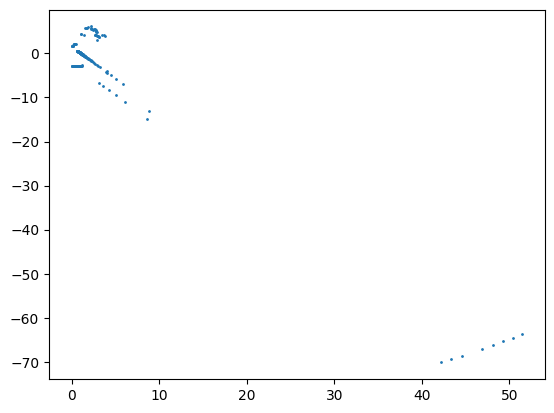

In [167]:
_xs, _ys = points[i, :, 0], points[i, :, 1]
plt.scatter(_xs, _ys, s=1)
i += 50

print(i)

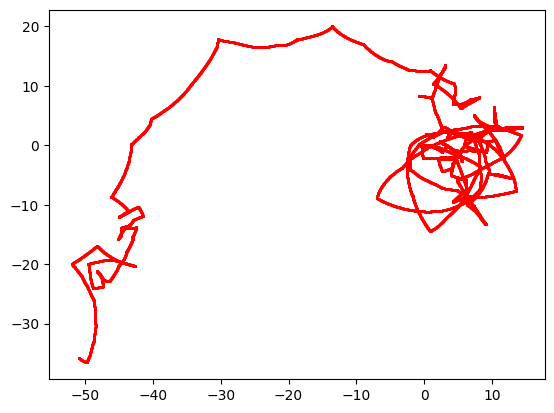

In [170]:
_xs, _ys = poses[:, 0], poses[:, 1]
plt.scatter(_xs, _ys, s=1, color='r')

In [7]:
import numpy as np
from einops import rearrange
import time

x = np.random.rand(100, 200, 300)

# Rearrange with einops
start = time.perf_counter()
y1 = rearrange(x, 'a b c -> a c b')
print("einops:", time.perf_counter() - start)

# Rearrange with NumPy
start = time.perf_counter()
y2 = np.transpose(x, (0, 2, 1))
print("numpy :", time.perf_counter() - start)

assert np.allclose(y1, y2)


einops: 5.476397927850485e-05
numpy : 0.00025196303613483906
